# Random Forest

## Importaciones

In [1]:
import time
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [4]:
from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold

In [6]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

## Cargado de datos

In [7]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 15), (42539, 15), (170152, 1), (42539, 1))

In [9]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

## Funciones usadas

In [10]:
from funciones import *

## Modelo randomforest

In [11]:
pipe_RF=crear_pipeline(RandomForestClassifier(random_state=0,max_depth=5,min_samples_leaf=3), tipo="normal")

In [12]:
start = time.time()
model_pipe = pipe_RF.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.48 minutos


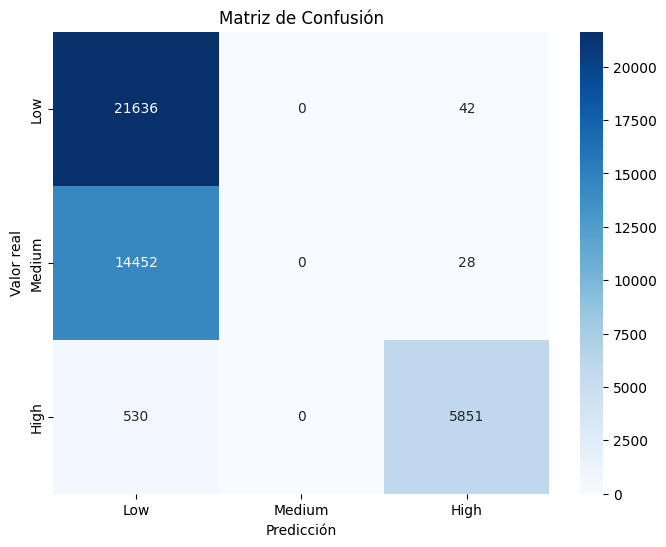


Classification Report:

              precision    recall  f1-score   support

         Low       0.59      1.00      0.74     21678
      Medium       0.00      0.00      0.00     14480
        High       0.99      0.92      0.95      6381

    accuracy                           0.65     42539
   macro avg       0.53      0.64      0.56     42539
weighted avg       0.45      0.65      0.52     42539



{'Accuracy': 0.6461599943581184,
 'Precision (macro)': 0.5263448760953442,
 'Recall (macro)': 0.6383344900824289,
 'F1-score (macro)': 0.5645027388911025,
 'ROC-AUC': 0.752668090419415}

In [13]:
evaluar_modelo(model_pipe, X_test, y_test)

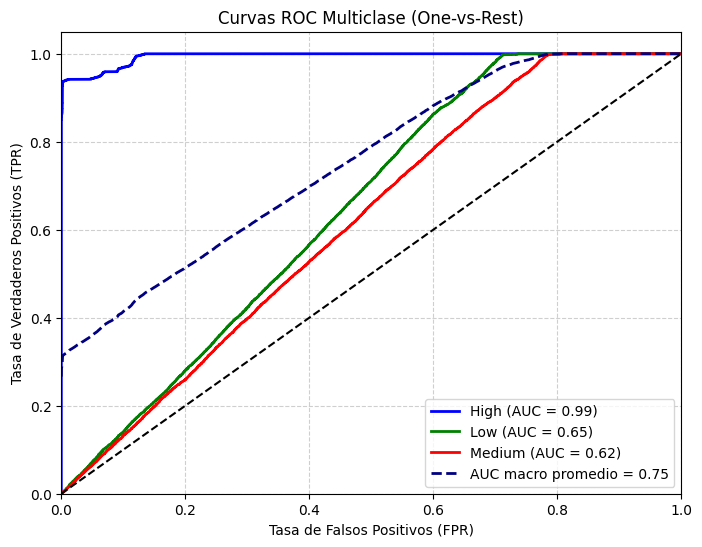


===== AUC por clase =====
High: 0.9942
Low: 0.6470
Medium: 0.6168
AUC macro promedio: 0.7527


({0: 0.9942190718981283, 1: 0.6470115917448288, 2: 0.6167736076152874},
 0.7526811797964201)

In [14]:
plot_roc_multiclass(model_pipe, X_test, y_test)

## Balance de modelos

### SMOTE

In [15]:
pipe_RF_bal=crear_pipeline(RandomForestClassifier(random_state=0,max_depth=5,min_samples_leaf=3), tipo="balanceo_smote")

In [16]:
start = time.time()
model_pipe_bal = pipe_RF_bal.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 1.23 minutos


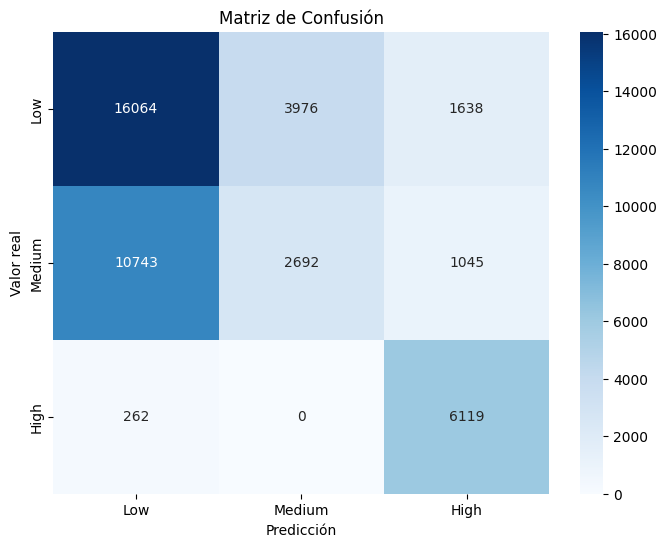


Classification Report:

              precision    recall  f1-score   support

         Low       0.59      0.74      0.66     21678
      Medium       0.40      0.19      0.25     14480
        High       0.70      0.96      0.81      6381

    accuracy                           0.58     42539
   macro avg       0.56      0.63      0.57     42539
weighted avg       0.54      0.58      0.54     42539



{'Accuracy': 0.5847575166317968,
 'Precision (macro)': 0.5641161822994697,
 'Recall (macro)': 0.6286266590734317,
 'F1-score (macro)': 0.5732320804767254,
 'ROC-AUC': 0.7519281434130111}

In [17]:
evaluar_modelo(model_pipe_bal, X_test, y_test)

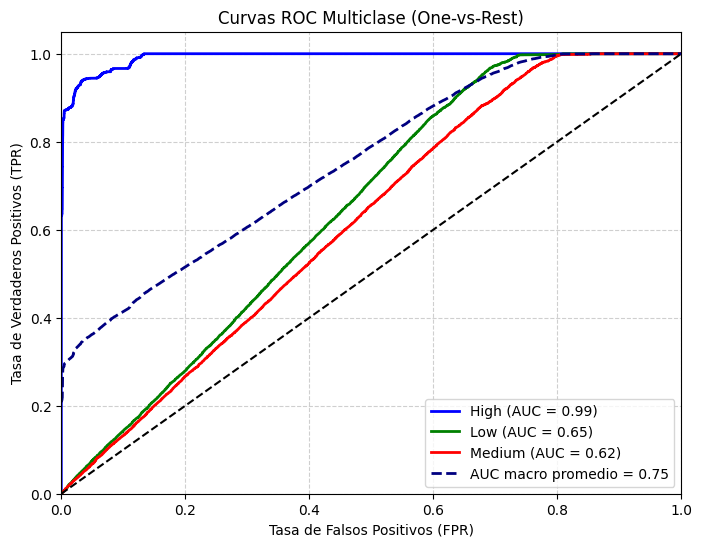


===== AUC por clase =====
High: 0.9923
Low: 0.6471
Medium: 0.6164
AUC macro promedio: 0.7519


({0: 0.9922886718626713, 1: 0.6471157324385146, 2: 0.6163800259378472},
 0.751935178642311)

In [18]:
plot_roc_multiclass(model_pipe_bal, X_test, y_test)

### ADASYN

In [19]:
pipe_RF_ads=crear_pipeline(RandomForestClassifier(random_state=0,max_depth=5,min_samples_leaf=3), tipo="balanceo_adasyn")

In [20]:
start = time.time()
model_pipe_ads = pipe_RF_ads.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 1.98 minutos


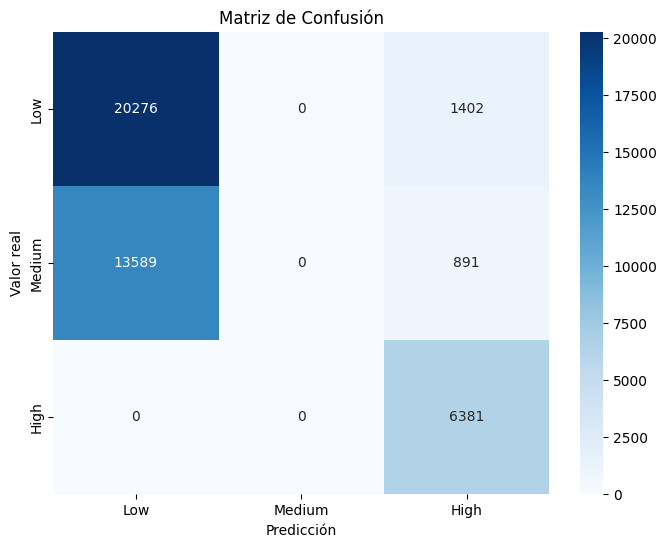


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.94      0.73     21678
      Medium       0.00      0.00      0.00     14480
        High       0.74      1.00      0.85      6381

    accuracy                           0.63     42539
   macro avg       0.44      0.65      0.53     42539
weighted avg       0.42      0.63      0.50     42539



{'Accuracy': 0.6266484872705047,
 'Precision (macro)': 0.44479233763551135,
 'Recall (macro)': 0.6451087123658393,
 'F1-score (macro)': 0.5259309331906353,
 'ROC-AUC': 0.7546695680618857}

In [21]:
evaluar_modelo(model_pipe_ads, X_test, y_test)

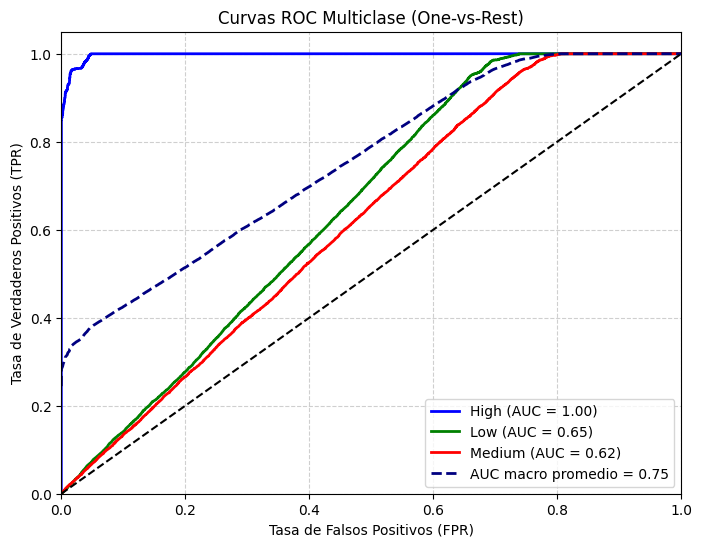


===== AUC por clase =====
High: 0.9977
Low: 0.6485
Medium: 0.6177
AUC macro promedio: 0.7547


({0: 0.997722531903654, 1: 0.6485479129826854, 2: 0.6177382592993177},
 0.7546759180884739)

In [22]:
plot_roc_multiclass(model_pipe_ads, X_test, y_test)

### Class weight balanced

In [23]:
pipe_RF_cw=crear_pipeline(RandomForestClassifier(random_state=0,class_weight='balanced',max_depth=5,min_samples_leaf=3), tipo="normal")

In [24]:
start = time.time()
model_pipe_cw = pipe_RF_cw.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.48 minutos


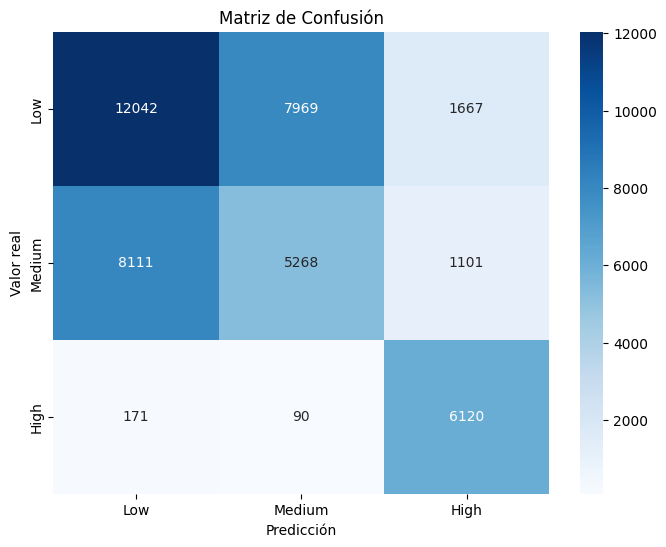


Classification Report:

              precision    recall  f1-score   support

         Low       0.59      0.56      0.57     21678
      Medium       0.40      0.36      0.38     14480
        High       0.69      0.96      0.80      6381

    accuracy                           0.55     42539
   macro avg       0.56      0.63      0.58     42539
weighted avg       0.54      0.55      0.54     42539



{'Accuracy': 0.5507886880274572,
 'Precision (macro)': 0.5587860315532914,
 'Recall (macro)': 0.6261345080439741,
 'F1-score (macro)': 0.5846409574830047,
 'ROC-AUC': 0.7526062319806476}

In [25]:
evaluar_modelo(model_pipe_cw, X_test, y_test)

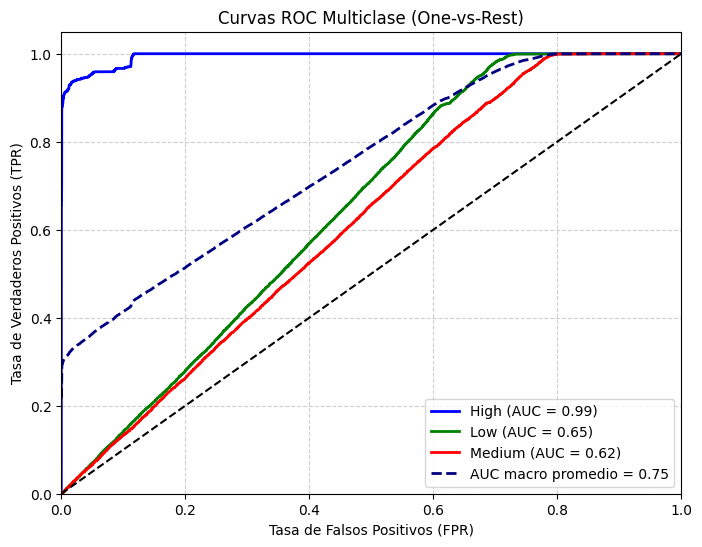


===== AUC por clase =====
High: 0.9942
Low: 0.6470
Medium: 0.6166
AUC macro promedio: 0.7526


({0: 0.9941533050642568, 1: 0.6470417570547962, 2: 0.6166236338228899},
 0.752618215896079)

In [26]:
plot_roc_multiclass(model_pipe_cw, X_test, y_test)

## Tabla comparativa

| RandomForest      | Accuracy | Precision_macro | Recall_macro | F1-macro | AUC  | Tiempo en minutos
|---------------|----------|----------|--------|----------|------|------|
| Benchmark      | 0.65     | 0.53     | 0.64   | 0.56    | 0.75 | 0.85
| SMOTE     | 0.58    | 0.56     | 0.63   | 0.57     | 0.75 | 0.33
| ADASYN     | 0.63    | 0.44     | 0.65   | 0.53    | 0.75 |1.00
| class_weight     | 0.64     | 0.56     | 0.63   | 0.58     | 0.75 | 0.08 